In [ ]:
!unzip -q auta.zip -d dataset/

In [ ]:
!unzip -q cars.zip -d kaggle_cars_collection/

In [ ]:
import os, torch, random, json
import numpy as np
from glob import glob
from PIL import Image
from torch.utils.data import random_split, Dataset, DataLoader
from torchvision import transforms as T

Image.MAX_IMAGE_PIXELS = None
torch.manual_seed(2025)

class CustomDataset(Dataset):
    def __init__(self, roots, cls_names=None, transformations=None):
        self.transformations = transformations
        self.im_paths = []

        for r in roots:
            self.im_paths.extend(glob(f"{r}/*/*.jpg") + glob(f"{r}/*/*.png") + glob(f"{r}/*/*.jpeg") +
                                 glob(f"{r}/*.jpg") + glob(f"{r}/*.png") + glob(f"{r}/*.jpeg"))


        unikalne_marki = set()
        for im_path in self.im_paths:
            unikalne_marki.add(self.get_cls_name(im_path))

        posortowane_marki = sorted(list(unikalne_marki))

        self.cls_names = {marka: idx for idx, marka in enumerate(posortowane_marki)}
        self.cls_counts = {marka: 0 for marka in posortowane_marki}
        self.mapa_klas = {marka: [] for marka in posortowane_marki}

        for im_path in self.im_paths:
            cls_name = self.get_cls_name(im_path)
            self.mapa_klas[cls_name].append(im_path)
            self.cls_counts[cls_name] += 1

        self.lista_wszystkich_marek = list(self.mapa_klas.keys())

    def get_cls_name(self, path):
        nazwa_pliku = os.path.basename(path)
        nazwa_folderu = os.path.basename(os.path.dirname(path))

        if nazwa_pliku.count('_') > 5:
            surowa_nazwa = nazwa_pliku.split('_')[0]
        else:
            surowa_nazwa = nazwa_folderu

        slownik_naprawczy = {
            'MINI': 'Mini',
            'INFINITI': 'Infiniti',
            'FIAT': 'Fiat',
            'smart': 'Smart'
        }
        return slownik_naprawczy.get(surowa_nazwa, surowa_nazwa)

    def __len__(self):
        return len(self.im_paths)

    def get_pos_neg_im_paths(self, qry_label):
        pos_im_path = random.choice(self.mapa_klas[qry_label])

        neg_label = random.choice(self.lista_wszystkich_marek)
        while neg_label == qry_label:
            neg_label = random.choice(self.lista_wszystkich_marek)

        neg_im_path = random.choice(self.mapa_klas[neg_label])

        return pos_im_path, neg_im_path

    def __getitem__(self, idx):
        im_path = self.im_paths[idx]
        qry_im = Image.open(im_path).convert("RGB")
        qry_label = self.get_cls_name(im_path)

        pos_im_path, neg_im_path = self.get_pos_neg_im_paths(qry_label=qry_label)
        pos_im, neg_im = Image.open(pos_im_path).convert("RGB"), Image.open(neg_im_path).convert("RGB")

        qry_gt = self.cls_names[qry_label]
        neg_gt = self.cls_names[self.get_cls_name(neg_im_path)]

        if self.transformations is not None:
            qry_im = self.transformations(qry_im)
            pos_im = self.transformations(pos_im)
            neg_im = self.transformations(neg_im)

        data = {
            "qry_im": qry_im,
            "qry_gt": qry_gt,
            "pos_im": pos_im,
            "neg_im": neg_im,
            "neg_gt": neg_gt
        }
        return data

def get_dls(roots, transformations, bs, split=[0.8, 0.1, 0.1], ns=2):
    ds = CustomDataset(roots=roots, transformations=transformations)
    cls_names = ds.cls_names
    cls_counts = ds.cls_counts

    total_len = len(ds)
    tr_len = int(total_len * split[0])
    vl_len = int(total_len * split[1])
    ts_len = total_len - tr_len - vl_len

    tr_ds, vl_ds, ts_ds = random_split(dataset=ds, lengths=[tr_len, vl_len, ts_len])

    tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=ns)
    val_dl = DataLoader(vl_ds, batch_size=bs, shuffle=False, num_workers=ns)
    ts_dl = DataLoader(ts_ds, batch_size=1, shuffle=False, num_workers=ns)

    return tr_dl, val_dl, ts_dl, cls_names, cls_counts

katalogi_z_danymi = ["dataset", "kaggle_cars_collection"]

mean, std, size, bs = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 224, 16
tfs = T.Compose([T.ToTensor(), T.Resize(size=(size, size), antialias=False), T.Normalize(mean=mean, std=std)])

print(" Przygotowuję połączoną bazę danych (Triplet Loss)...")
tr_dl, val_dl, ts_dl, classes, cls_counts = get_dls(roots=katalogi_z_danymi, transformations=tfs, bs=bs)

with open("slownik_marek.json", "w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False, indent=4)

print(f" Łączna ilość unikalnych marek w bazie: {len(classes)}")
print(f" Pierwsze marki na liście: {list(classes.keys())[:10]}")
print(" Słownik został bezpiecznie zapisany w pliku: 'slownik_marek.json'!")

 Przygotowuję połączoną bazę danych (Triplet Loss)...
 Łączna ilość unikalnych marek w bazie: 55
 Pierwsze marki na liście: ['Acura', 'Alfa Romeo', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet']
 Słownik został bezpiecznie zapisany w pliku: 'slownik_marek.json'!


In [ ]:
print(classes)

{'Acura': 0, 'Alfa Romeo': 1, 'Aston Martin': 2, 'Audi': 3, 'BMW': 4, 'Bentley': 5, 'Bugatti': 6, 'Buick': 7, 'Cadillac': 8, 'Chevrolet': 9, 'Chrysler': 10, 'Citroen': 11, 'Daewoo': 12, 'Dodge': 13, 'Ferrari': 14, 'Fiat': 15, 'Ford': 16, 'GMC': 17, 'Genesis': 18, 'Honda': 19, 'Hudson': 20, 'Hyundai': 21, 'Infiniti': 22, 'Jaguar': 23, 'Jeep': 24, 'Kia': 25, 'Lamborghini': 26, 'Land Rover': 27, 'Lexus': 28, 'Lincoln': 29, 'MG': 30, 'Maserati': 31, 'Mazda': 32, 'McLaren': 33, 'Mercedes-Benz': 34, 'Mini': 35, 'Mitsubishi': 36, 'Nissan': 37, 'Oldsmobile': 38, 'Peugeot': 39, 'Pontiac': 40, 'Porsche': 41, 'Ram': 42, 'Ram Trucks': 43, 'Renault': 44, 'Rolls-Royce': 45, 'Saab': 46, 'Smart': 47, 'Studebaker': 48, 'Subaru': 49, 'Suzuki': 50, 'Tesla': 51, 'Toyota': 52, 'Volkswagen': 53, 'Volvo': 54}


In [ ]:
import timm
import torch.nn as nn
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Silnik graficzny: {device}")

print(" Pobieranie architektury ResNet50 z wagami ImageNet...")
model = timm.create_model('resnet50', pretrained=True, num_classes=len(classes))
model = model.to(device)

ce_loss_fn = nn.CrossEntropyLoss()
cs_loss_fn = nn.CosineEmbeddingLoss(margin=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 15
best_acc = 0.0

print("\n ROZPOCZYNANIE ZAAWANSOWANEGO TRENINGU ")

for epoch in range(epochs):
    model.train()
    train_acc, train_loss = 0, 0

    print(f"\n--- Epoka {epoch+1}/{epochs} ---")

    for batch in tqdm(tr_dl, desc="Uczenie sieci", colour="green"):
        qry_im = batch["qry_im"].to(device)
        pos_im = batch["pos_im"].to(device)
        neg_im = batch["neg_im"].to(device)
        qry_gt = batch["qry_gt"].to(device)

        curr_bs = qry_im.shape[0]
        optimizer.zero_grad()

        qry_logits = model(qry_im)
        pos_logits = model(pos_im)

        qry_features = model.forward_features(qry_im).mean(dim=[2,3])
        pos_features = model.forward_features(pos_im).mean(dim=[2,3])
        neg_features = model.forward_features(neg_im).mean(dim=[2,3])

        ce_loss = ce_loss_fn(qry_logits, qry_gt) + ce_loss_fn(pos_logits, qry_gt)

        cs_pos_lbl = torch.ones(curr_bs).to(device)
        cs_neg_lbl = -torch.ones(curr_bs).to(device)
        cs_loss = cs_loss_fn(qry_features, pos_features, cs_pos_lbl) + cs_loss_fn(qry_features, neg_features, cs_neg_lbl)

        loss = ce_loss + cs_loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += (torch.argmax(qry_logits, dim=1) == qry_gt).sum().item()

    model.eval()
    val_acc = 0
    with torch.no_grad():
        for batch in tqdm(val_dl, desc="Walidacja", colour="blue"):
            qry_im = batch["qry_im"].to(device)
            qry_gt = batch["qry_gt"].to(device)
            logits = model(qry_im)
            val_acc += (torch.argmax(logits, dim=1) == qry_gt).sum().item()

    t_acc = train_acc / len(tr_dl.dataset)
    v_acc = val_acc / len(val_dl.dataset)

    print(f" Dokładność (Trening): {t_acc*100:.2f}%")
    print(f" Dokładność (Walidacja): {v_acc*100:.2f}%")

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'najlepszy_model_pytorch.pth')
        print(" Znaleziono lepsze parametry! Zapisuje 'najlepszy_model_pytorch.pth'")

print(f"\n Proces zakończony. Maksymalna skuteczność walidacyjna: {best_acc*100:.2f}%")

 Silnik graficzny: cuda
 Pobieranie architektury ResNet50 z wagami ImageNet...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


 ROZPOCZYNANIE ZAAWANSOWANEGO TRENINGU 

--- Epoka 1/15 ---


Walidacja: 100%|██████████| 432/432 [00:31<00:00, 13.62it/s]


 Dokładność (Trening): 31.97%
 Dokładność (Walidacja): 54.92%
 Znaleziono lepsze parametry! Zapisuje 'najlepszy_model_pytorch.pth'

--- Epoka 2/15 ---


...

 Dokładność (Trening): 99.29%
 Dokładność (Walidacja): 98.57%
 Znaleziono lepsze parametry! Zapisuje 'najlepszy_model_pytorch.pth'

--- Epoka 14/15 ---


Walidacja: 100%|██████████| 432/432 [00:32<00:00, 13.38it/s]


 Dokładność (Trening): 99.34%
 Dokładność (Walidacja): 98.86%
 Znaleziono lepsze parametry! Zapisuje 'najlepszy_model_pytorch.pth'

--- Epoka 15/15 ---


Walidacja: 100%|██████████| 432/432 [00:31<00:00, 13.57it/s]


 Dokładność (Trening): 99.41%
 Dokładność (Walidacja): 99.13%
 Znaleziono lepsze parametry! Zapisuje 'najlepszy_model_pytorch.pth'

 Proces zakończony. Maksymalna skuteczność walidacyjna: 99.13%



 Analiza statystyczna zbioru walidacyjnego...
 Generowanie wizualizacji siatki błędów...


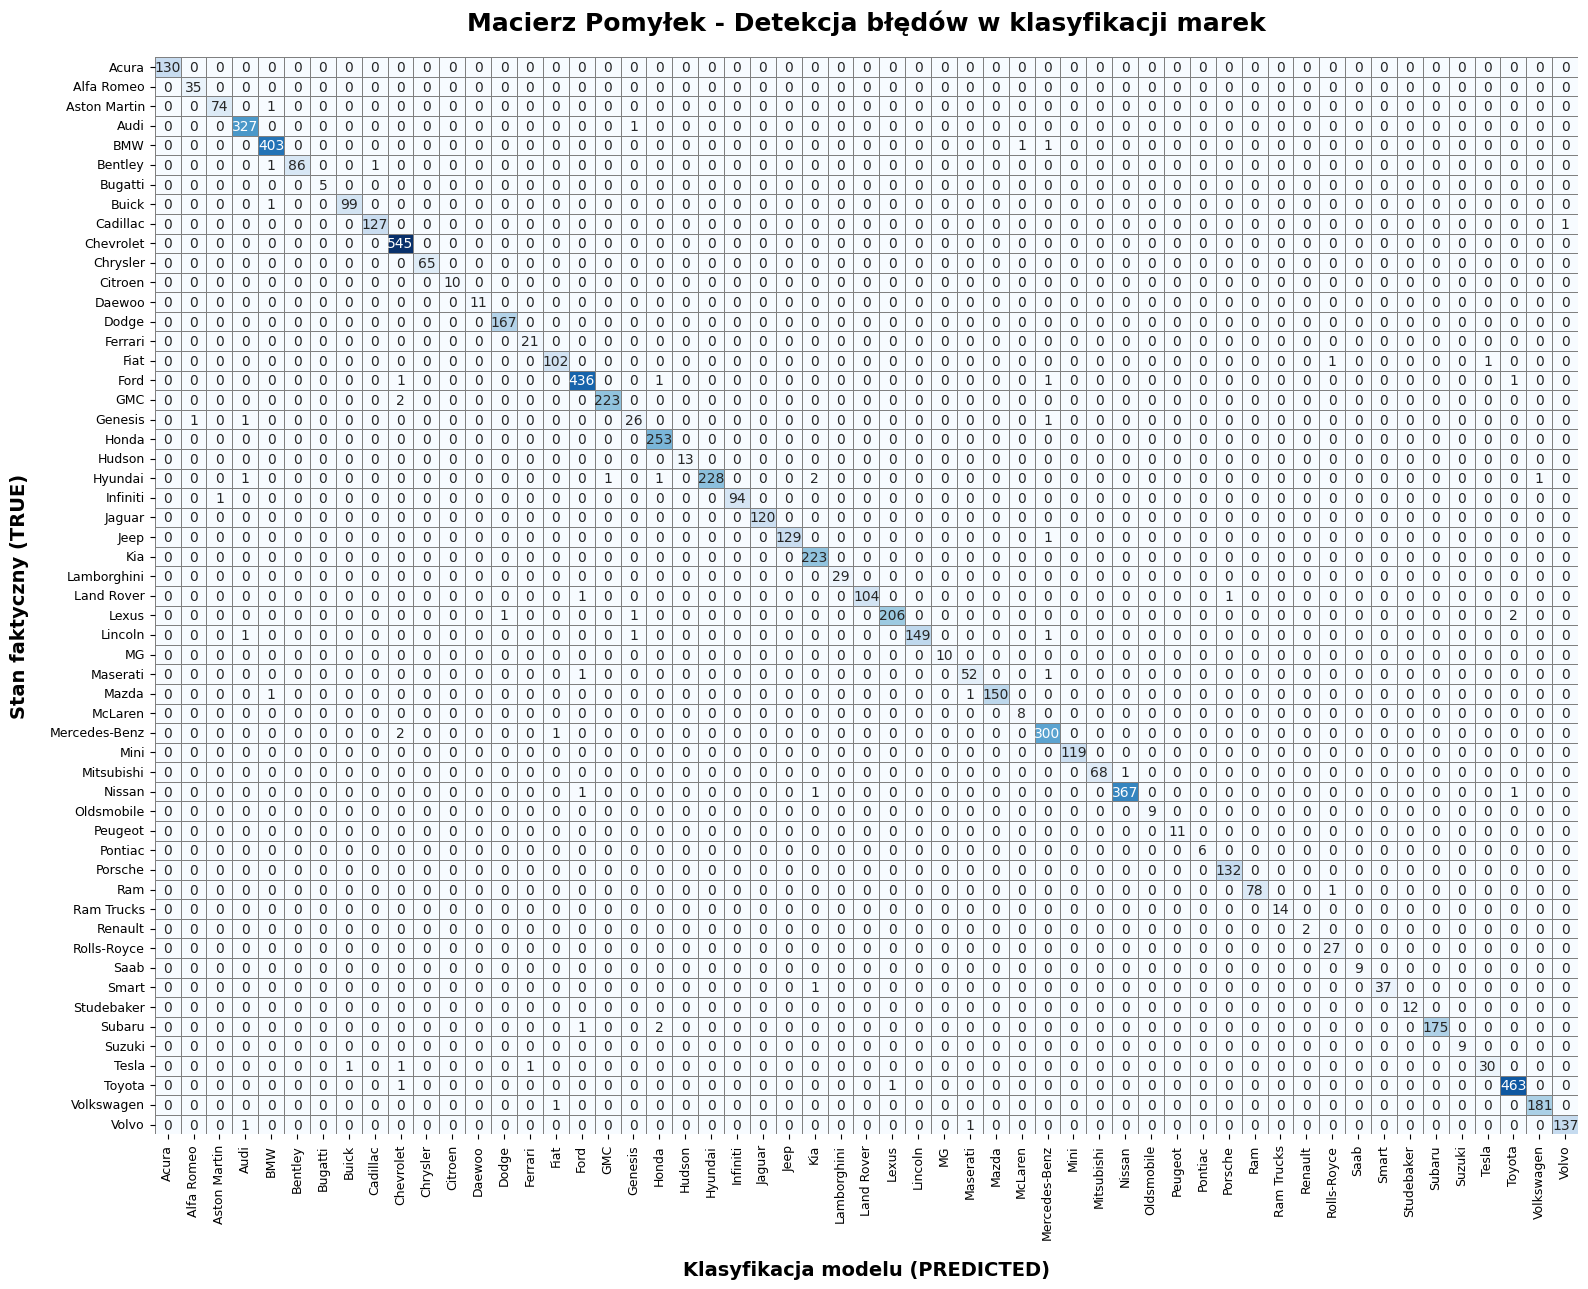

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

print("\n Analiza statystyczna zbioru walidacyjnego...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

y_prawdziwe = []
y_przewidziane = []

nazwy_klas = [k for k, v in sorted(classes.items(), key=lambda item: item[1])]

with torch.no_grad():
    for batch in val_dl:
        qry_im = batch["qry_im"].to(device)
        qry_gt = batch["qry_gt"].to(device)

        logits = model(qry_im)
        preds = torch.argmax(logits, dim=1)

        y_prawdziwe.extend(qry_gt.cpu().numpy())
        y_przewidziane.extend(preds.cpu().numpy())

print(" Generowanie wizualizacji siatki błędów...")
cm = confusion_matrix(y_prawdziwe, y_przewidziane)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nazwy_klas, yticklabels=nazwy_klas,
            cbar=False, linewidths=0.5, linecolor='gray')

plt.xlabel('Klasyfikacja modelu (PREDICTED)', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Stan faktyczny (TRUE)', fontsize=14, fontweight='bold', labelpad=15)
plt.title('Macierz Pomyłek - Detekcja błędów w klasyfikacji marek', fontsize=18, fontweight='bold', pad=20)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms as T
from PIL import Image

print("\n TEST - POJEDYNCZY OBRAZ...")
sciezka_do_zdjecia = 'autko.jpg'

size = 224
tfs_testowe = T.Compose([
    T.Resize(size=(size, size), antialias=False),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    obrazek = Image.open(sciezka_do_zdjecia).convert("RGB")
    obrazek_tensor = tfs_testowe(obrazek).unsqueeze(0).to(device)

    model.load_state_dict(torch.load('najlepszy_model_pytorch.pth', map_location=device, weights_only=True))
    model.eval()

    odwrotne_klasy = {v: k for k, v in classes.items()}

    with torch.no_grad():
        wyniki = model(obrazek_tensor)
        prawdopodobienstwa = F.softmax(wyniki, dim=1)[0]
        top3_pewnosc, top3_indeksy = torch.topk(prawdopodobienstwa, 3)

    print("\n" + "="*50)
    print(f" RAPORT DETEKCJI DLA PLIKU: {sciezka_do_zdjecia}")
    print("="*50)

    for i in range(3):
        procent = top3_pewnosc[i].item() * 100
        marka = odwrotne_klasy[top3_indeksy[i].item()]

        if i == 0:
            print(f" 1. POZYCJA: {marka.upper():<20} ({procent:.1f}% pewności)")
        else:
            print(f"   {i+1}. POZYCJA: {marka:<20} ({procent:.1f}%)")
    print("="*50)

except FileNotFoundError:
    print(f"❌ BŁĄD SYSTEMU PLIKÓW: Nie odnaleziono pliku o nazwie '{sciezka_do_zdjecia}'. Upewnij się, czy został poprawnie przesłany do katalogu głównego Colaba.")
except Exception as e:
    print(f"❌ WYSTĄPIŁ NIEOCZEKIWANY BŁĄD: {e}")


 TEST - POJEDYNCZY OBRAZ...

 RAPORT DETEKCJI DLA PLIKU: autko.jpg
 1. POZYCJA: FIAT                 (100.0% pewności)
   2. POZYCJA: Smart                (0.0%)
   3. POZYCJA: Rolls-Royce          (0.0%)


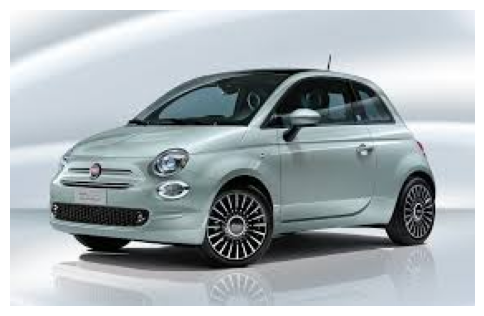


 RAPORT DETEKCJI DLA PLIKU: autko.jpg
 1. POZYCJA: FIAT                 (100.0% pewności)
   2. POZYCJA: Smart                (0.0%)
   3. POZYCJA: Rolls-Royce          (0.0%)


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np
import timm
import matplotlib.pyplot as plt

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        return TF.pad(image, (hp, vp, hp, vp), 0, 'constant')

classes = classes = {
    "Acura": 0,
    "Alfa Romeo": 1,
    "Aston Martin": 2,
    "Audi": 3,
    "BMW": 4,
    "Bentley": 5,
    "Bugatti": 6,
    "Buick": 7,
    "Cadillac": 8,
    "Chevrolet": 9,
    "Chrysler": 10,
    "Citroen": 11,
    "Daewoo": 12,
    "Dodge": 13,
    "Ferrari": 14,
    "Fiat": 15,
    "Ford": 16,
    "GMC": 17,
    "Genesis": 18,
    "Honda": 19,
    "Hudson": 20,
    "Hyundai": 21,
    "Infiniti": 22,
    "Jaguar": 23,
    "Jeep": 24,
    "Kia": 25,
    "Lamborghini": 26,
    "Land Rover": 27,
    "Lexus": 28,
    "Lincoln": 29,
    "MG": 30,
    "Maserati": 31,
    "Mazda": 32,
    "McLaren": 33,
    "Mercedes-Benz": 34,
    "Mini": 35,
    "Mitsubishi": 36,
    "Nissan": 37,
    "Oldsmobile": 38,
    "Peugeot": 39,
    "Pontiac": 40,
    "Porsche": 41,
    "Ram": 42,
    "Ram Trucks": 43,
    "Renault": 44,
    "Rolls-Royce": 45,
    "Saab": 46,
    "Smart": 47,
    "Studebaker": 48,
    "Subaru": 49,
    "Suzuki": 50,
    "Tesla": 51,
    "Toyota": 52,
    "Volkswagen": 53,
    "Volvo": 54
}

odwrotne_klasy = {v: k for k, v in classes.items()}

sciezka_do_zdjecia = 'autko.jpg'
sciezka_do_wag = 'najlepszy_model_pytorch.pth'

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = timm.create_model('resnet50', pretrained=False, num_classes=len(classes))
    model.to(device)
    model.load_state_dict(torch.load(sciezka_do_wag, map_location=device, weights_only=True))
    model.eval()

    tfs_testowe = T.Compose([
    T.Resize(size=(224, 224), antialias=False),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

    obrazek = Image.open(sciezka_do_zdjecia).convert("RGB")
    obrazek_tensor = tfs_testowe(obrazek).unsqueeze(0).to(device)

    with torch.no_grad():
        wyniki = model(obrazek_tensor)
        prawdopodobienstwa = F.softmax(wyniki, dim=1)[0]
        top3_pewnosc, top3_indeksy = torch.topk(prawdopodobienstwa, 3)

    plt.figure(figsize=(6, 6))
    plt.imshow(obrazek)
    plt.axis('off')
    plt.show()

    print("\n" + "="*50)
    print(f" RAPORT DETEKCJI DLA PLIKU: {sciezka_do_zdjecia}")
    print("="*50)

    for i in range(3):
        procent = top3_pewnosc[i].item() * 100
        marka = odwrotne_klasy[top3_indeksy[i].item()]

        if i == 0:
            print(f" 1. POZYCJA: {marka.upper():<20} ({procent:.1f}% pewności)")
        else:
            print(f"   {i+1}. POZYCJA: {marka:<20} ({procent:.1f}%)")
    print("="*50)

except FileNotFoundError as e:
    print(f" BŁĄD PLIKU: Upewnij się, że wgrałeś model i zdjęcie do Colaba.")
except Exception as e:
    print(f" WYSTĄPIŁ BŁĄD: {e}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/auta.zip -d /content/dataset
!unzip -q /content/drive/MyDrive/cars.zip -d /content/kaggle_cars_collection